# Análise de Comportamento no Spotify

## Objetivo
Este notebook realiza uma análise exploratória e modelagem para entender:
- Padrões de consumo musical
- Comportamento de skip
- Preferências por gênero
- Predição de skip a partir de features de uso


## Passo 0: Importação de bibliotecas e preparação do ambiente


In [66]:
import os
import json
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression

## Passo 1: Carregamento e consolidação dos dados

Nesta etapa os arquivos brutos são lidos e combinados em um único DataFrame.


In [34]:
caminho_pasta = "../data/raw"

lista_dfs = []

for arquivo in os.listdir(caminho_pasta):
    if arquivo.endswith(".json"):
        caminho_completo = os.path.join(caminho_pasta, arquivo)
        
        with open(caminho_completo, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        df_temp = pd.DataFrame(data)
        lista_dfs.append(df_temp)

df_final = pd.concat(lista_dfs, ignore_index=True)

print(df_final.shape)

(328193, 26)


### Visualização inicial dos dados

Exibimos as primeiras linhas para validar a estrutura.


In [35]:
display(df_final.head())

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,user,artist_id,genre
0,2023-11-03T19:04:26Z,windows,153600,BR,200.185.254.31,Ooo La La,Rozei,Ooo La La,spotify:track:0jfIQheXtPPOX0PSn2xxdH,None,...,trackdone,trackdone,True,False,False,1.699038e+09,False,gigi,4KDCtEFisBruCfqakuV4PZ,[]
1,2023-11-03T19:06:55Z,windows,147777,BR,200.185.254.31,Quarter Milli (feat. Gucci Mane),Offset,FATHER OF 4,spotify:track:36YZKsGtyzblj9fGYKtR7H,None,...,trackdone,endplay,True,True,False,1.699038e+09,False,gigi,0iEtIxbK0KxaSlF7G42ZOp,[]
2,2023-11-03T19:08:49Z,windows,114865,BR,200.185.254.31,Costa Rica (feat. The Kid LAROI) - Remix,Bankrol Hayden,Pain is Temporary,spotify:track:3tdjTdCCgKtwacsICCtPZZ,None,...,clickrow,trackdone,False,False,False,1.699038e+09,False,gigi,0Yr4BBpK2dkCp2UsrJ9LZN,[melodic rap]
3,2023-11-03T19:10:42Z,windows,111054,BR,200.185.254.31,Diva (feat. Lil Tecca),The Kid LAROI,Diva (feat. Lil Tecca),spotify:track:7gVwgc8b3XnO87TpmXXFA5,None,...,trackdone,endplay,False,True,False,1.699039e+09,False,gigi,2tIP7SsRs7vjIcLrU85W8J,[]
4,2023-11-03T19:12:12Z,windows,90010,BR,191.23.42.158,Blueberry Faygo,Lil Mosey,Blueberry Faygo,spotify:track:6wJYhPfqk3KGhHRG76WzOh,None,...,playbtn,unexpected-exit,False,False,False,1.699039e+09,False,gigi,6Xgp2XMz1fhVYe7i6yNAax,[melodic rap]


### Preparação dos dados

In [36]:
df = df_final.copy()

# Converter timestamp
df["ts"] = pd.to_datetime(df["ts"])

# Explodir gêneros
df_genre = df.explode("genre")

# Remover nulos
df_genre = df_genre[df_genre["genre"].notna()]

# Converter ms para minutos
df_genre["minutes_played"] = df_genre["ms_played"] / 60000

## Passo 2: Funções auxiliares para visualização

Funções reutilizáveis para facilitar a análise gráfica das variáveis.


In [37]:
def gerar_grafico_colunas(df,titulo=' '):
    fig = px.bar(df,title=titulo)
    fig.show()

## Passo 3: Análise de consumo por gênero

Avaliação do tempo total e participação relativa de cada gênero.


In [38]:
genre_time = (
    df_genre
    .groupby("genre")["minutes_played"]
    .sum()
    .sort_values(ascending=False)
)

In [39]:
genre_share = genre_time / genre_time.sum()
gerar_grafico_colunas(genre_share.head(15),'Generos mais ouvidos por percentual de minutos')

### Skips behavior por genero

In [40]:
skip_rate = (
    df_genre
    .groupby("genre")["skipped"]
    .mean()
)
gerar_grafico_colunas(skip_rate.drop_duplicates().sort_values(ascending=False).head(15),'Generos com maior quantidade de Skips')
gerar_grafico_colunas(skip_rate.drop_duplicates().sort_values(ascending=True).head(15),'Generos com menor quantidade de Skips')

In [41]:
avg_time_before_skip = (
    df_genre[df_genre["skipped"] == True]
    .groupby("genre")["minutes_played"]
    .mean()
    .sort_values()
)
gerar_grafico_colunas(avg_time_before_skip.sort_values(ascending=False).head(15),'Tempo médio antes de skipar por Gênero')


In [42]:
genre_analysis = pd.concat(
    [genre_share, skip_rate],
    axis=1
)

genre_analysis.columns = ["market_share", "skip_rate"]
genre_analysis["skip_adjusted_score"] = (
    genre_analysis["market_share"] * (1 - genre_analysis["skip_rate"])
)

genre_analysis.sort_values("skip_adjusted_score", ascending=False).head(15)

,market_share,skip_rate,skip_adjusted_score
genre,,,
brazilian hip hop,0.058171,0.288042,0.041416
brazilian trap,0.053780,0.300849,0.037600
rock,0.052644,0.288570,0.037453
trap funk,0.052165,0.303193,0.036349
trap,0.044491,0.298276,0.031220
mpb,0.037960,0.334639,0.025257
rap,0.029740,0.223878,0.023082
brazilian pop,0.034166,0.334323,0.022744
brazilian rock,0.034293,0.336989,0.022737


## Passo 4: Diversificação musical

Cálculo da entropia para medir o nível de diversidade nos gêneros ouvidos.
Entropia por tempo (quanto mais próximo de 1 vc concentra tempo em mais generos)


In [43]:
p = genre_share.values
p = p[p > 0] 

entropy = -np.sum(p * np.log(p))
entropy
max_entropy = np.log(len(p))
normalized_entropy = entropy / max_entropy
normalized_entropy

np.float64(0.6565220235083193)

In [44]:
print("Entropia por frequência:", entropy)

Entropia por frequência: 4.134190952976124


## Passo 5: Evolução da diversidade ao longo do tempo


In [45]:
df_genre["year_month"] = df_genre["ts"].dt.to_period("M")

monthly_entropy = []

for period, group in df_genre.groupby("year_month"):
    p = (
        group["genre"]
        .value_counts(normalize=True)
        .values
    )
    h = -np.sum(p * np.log(p))
    monthly_entropy.append((period, h))

monthly_entropy_df = pd.DataFrame(monthly_entropy, columns=["period", "entropy"])
monthly_entropy_df.set_index("period", inplace=True)

C:\Users\fernandopaiva-ieg\AppData\Local\Temp\ipykernel_17860\3286335655.py:1: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



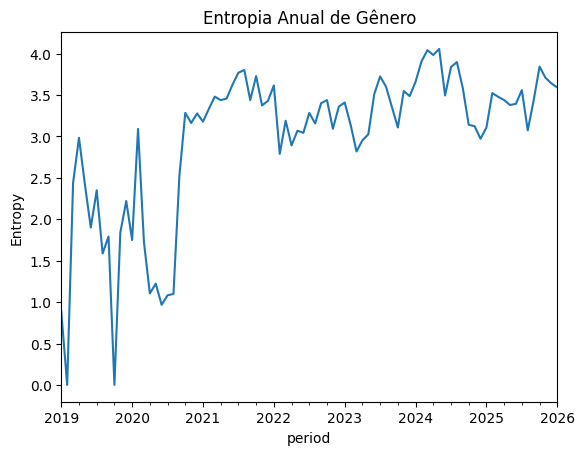

In [46]:
plt.figure()
monthly_entropy_df["entropy"].plot()
plt.title("Entropia Anual de Gênero")
plt.ylabel("Entropy")
plt.show()

## Passo 6: Correlação entre skip e tempo em minutos


In [47]:
df_genre["skip_numeric"] = df_genre["skipped"].astype(int)

correlation = df_genre[["minutes_played", "skip_numeric"]].corr()
correlation

,minutes_played,skip_numeric
minutes_played,1.00000,-0.51548
skip_numeric,-0.51548,1.00000


### Índice de tolerância por gênero

Compara o tempo médio das músicas ouvidas vs. puladas.


In [48]:
tolerance = (
    df_genre
    .groupby("genre")
    .apply(lambda x: 
           x[x["skipped"] == False]["minutes_played"].mean() /
           x["minutes_played"].mean()
          )
)

tolerance.sort_values(ascending=False).head(15)

C:\Users\fernandopaiva-ieg\AppData\Local\Temp\ipykernel_17860\2451065850.py:5: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\fernandopaiva-ieg\AppData\Local\Temp\ipykernel_17860\2451065850.py:4: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



genre
turreo                       6.264517
rkt                          6.264517
downtempo                    6.204885
riot grrrl                   5.962515
amapiano                     4.415798
gqom                         4.415798
raï                          3.621002
funk gospel                  3.519553
red dirt                     3.513940
zouk                         3.311988
italian singer-songwriter    3.292733
italian trap                 3.048186
experimental hip hop         2.826835
baltimore club               2.788976
philly club                  2.788976
dtype: float64

### Entropia condicional de skip

Mede a incerteza do comportamento de skip dentro de cada gênero.


In [49]:
def binary_entropy(p):
    if p in [0,1]:
        return 0
    return -p*np.log(p) - (1-p)*np.log(1-p)

skip_entropy_by_genre = skip_rate.apply(binary_entropy)
skip_entropy_by_genre.sort_values(ascending=False).head(15)

genre
ambient jazz          0.693147
shibuya-kei           0.693147
sexy drill            0.693147
ranchera              0.693147
roots reggae          0.693147
retro soul            0.693147
bachata               0.693147
aussie drill          0.693147
opera                 0.693147
outlaw country        0.693147
portuguese hip hop    0.693147
christian folk        0.693147
latin r&b             0.693147
kizomba               0.693147
traditional music     0.693147
Name: skipped, dtype: float64

## Passo 7: Feature Engineering e preparação para modelagem


In [50]:
df = df_genre.copy()

df["skip_numeric"] = df["skipped"].astype(int)
df["minutes_played"] = df["ms_played"] / 60000
df["ts"] = pd.to_datetime(df["ts"])

df = df[df["genre"].notna()]

In [51]:
df.columns

Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr',
       'master_metadata_track_name', 'master_metadata_album_artist_name',
       'master_metadata_album_album_name', 'spotify_track_uri', 'episode_name',
       'episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title',
       'reason_start', 'reason_end', 'shuffle', 'skipped', 'offline',
       'offline_timestamp', 'incognito_mode', 'user', 'artist_id', 'genre',
       'minutes_played', 'year_month', 'skip_numeric'],
      dtype='object')

In [70]:
df = df.sort_values(["user", "ts"]).reset_index(drop=True)

In [71]:
genre_time = df.groupby("genre")["minutes_played"].sum()
genre_share = genre_time / genre_time.sum()

skip_rate = df.groupby("genre")["skip_numeric"].mean()

genre_avg_time = df.groupby("genre")["minutes_played"].mean()

tolerance = (
    df.groupby("genre")
    .apply(lambda x:
           x[x["skip_numeric"] == 0]["minutes_played"].mean()
           / x["minutes_played"].mean()
           if x["minutes_played"].mean() > 0 else 0)
)



skip_entropy_by_genre = skip_rate.apply(binary_entropy)

genre_features = pd.DataFrame({
    "genre_skip_rate": skip_rate,
    "genre_skip_entropy": skip_entropy_by_genre,
    "genre_avg_time": genre_avg_time,
    "genre_tolerance": tolerance,
    "genre_market_share": genre_share
})

genre_features = genre_features.fillna(0)

C:\Users\fernandopaiva-ieg\AppData\Local\Temp\ipykernel_17860\254221739.py:10: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [72]:
window = 5

df["recent_skip_rate_5"] = (
    df.groupby("user")["skip_numeric"]
      .shift(1)
      .rolling(window)
      .mean()
      .reset_index(level=0, drop=True)
)

In [73]:
df["skip_streak"] = (
    df.groupby("user")["skip_numeric"]
      .apply(lambda x: x.shift(1)
                       .groupby((x.shift(1) != 1).cumsum())
                       .cumsum())
      .reset_index(level=0, drop=True)
)

df["skip_streak"] = df["skip_streak"].fillna(0)

In [74]:
df["tracks_since_last_skip"] = (
    df.groupby("user")["skip_numeric"]
      .apply(lambda x: x.shift(1)
                       .groupby((x.shift(1) == 1).cumsum())
                       .cumcount())
      .reset_index(level=0, drop=True)
)

In [76]:
df["prev_genre"] = df.groupby("user")["genre"].shift(1)

df["genre_switch"] = (df["genre"] != df["genre"]).astype(int)

df["genre_switch"] = df["genre_switch"].fillna(0)

In [78]:
def recent_genre_match(group, window=5):
    genres = group["genre"].values
    result = []

    for i in range(len(genres)):
        if i == 0:
            result.append(0)
            continue
        
        start = max(0, i-window)
        recent = genres[start:i]
        current = genres[i]
        
        match_rate = (recent == current).mean() if len(recent) > 0 else 0
        result.append(match_rate)
    
    return pd.Series(result, index=group.index)

df["recent_genre_match_5"] = (
    df.groupby("user")
      .apply(lambda x: recent_genre_match(x, window=5))
      .reset_index(level=0, drop=True)
)

C:\Users\fernandopaiva-ieg\AppData\Local\Temp\ipykernel_17860\770217047.py:21: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [84]:
df["recent_genre_skip_rate"] = (
    df.groupby(["user", "genre"])["skip_numeric"]
      .shift(1)
      .rolling(5)
      .mean()
)

In [86]:
genre_features.columns

Index(['genre_skip_rate', 'genre_skip_entropy', 'genre_avg_time',
       'genre_tolerance', 'genre_market_share', 'genre_cluster'],
      dtype='object')

In [87]:
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(genre_features)

kmeans = KMeans(n_clusters=4, random_state=42)
genre_features["genre_cluster"] = kmeans.fit_predict(X_cluster)

In [88]:
df = df.merge(
    genre_features,
    left_on="genre",
    right_index=True,
    how="left"
)

In [90]:
df["hour"] = df["ts"].dt.hour
df["day_of_week"] = df["ts"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)
df["year_month"] = df["ts"].dt.to_period("M")

C:\Users\fernandopaiva-ieg\AppData\Local\Temp\ipykernel_17860\1844911186.py:4: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



In [91]:
monthly_entropy = []

for period, group in df.groupby("year_month"):
    p = group["genre"].value_counts(normalize=True).values
    h = -np.sum(p * np.log(p)) if len(p) > 1 else 0
    monthly_entropy.append((period, h))

monthly_entropy_df = pd.DataFrame(monthly_entropy, columns=["year_month", "entropy"])
monthly_entropy_dict = monthly_entropy_df.set_index("year_month")["entropy"].to_dict()

df["monthly_entropy"] = df["year_month"].map(monthly_entropy_dict)

# Flag top gênero
top_genres = genre_share.sort_values(ascending=False).head(5).index
df["is_top_genre"] = df["genre"].isin(top_genres).astype(int)

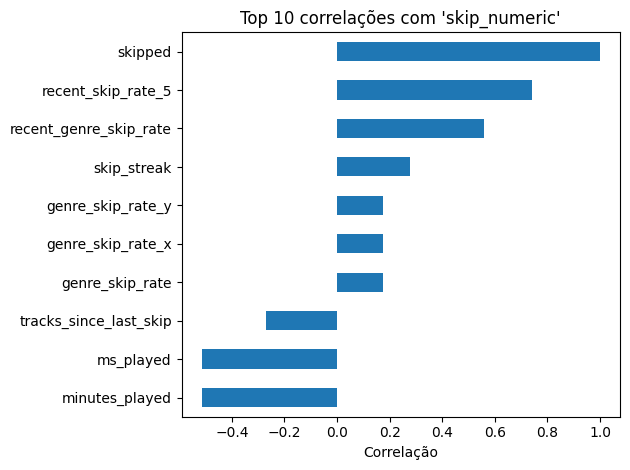

In [92]:
target = "skip_numeric"   
top_n = 10                


corr = df.corr(numeric_only=True)

corr_target = corr[target].drop(target)

top_corr = corr_target.sort_values(key=abs, ascending=False).head(top_n)

plt.figure()
top_corr.sort_values().plot(kind="barh")
plt.title(f"Top {top_n} correlações com '{target}'")
plt.xlabel("Correlação")
plt.tight_layout()
plt.show()

In [93]:
expected_features = [
    "genre_skip_rate",
    "genre_skip_entropy",
    "genre_avg_time",
    "genre_tolerance",
    "genre_market_share",
    "genre_cluster"
]

for col in expected_features:
    if col not in df.columns:
        print(f"Aviso: {col} não encontrado, criando como 0")
        df[col] = 0



features = [
    "shuffle",
    "hour",
    "is_weekend",
    "monthly_entropy",
    "genre_skip_rate",
    "genre_skip_entropy",
    "genre_avg_time",
    "genre_tolerance",
    "genre_market_share",
    "is_top_genre",
    "genre_cluster",
    "recent_skip_rate_5",
    "skip_streak",
    "tracks_since_last_skip",
    "genre_switch",
    "recent_genre_match_5",
    "recent_genre_skip_rate"
]

X = df[features].dropna()
y = df.loc[X.index, "skip_numeric"]

In [94]:
df_model = df.copy()

X = df_model[features]

y = df_model["skip_numeric"]

mask = X.notna().all(axis=1)

X = X[mask]
y = y[mask]

## Passo 8: Separação de dados para treino e teste


In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

## Passo 9: Treinamento do modelo de previsão de skip


In [96]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

pipeline = Pipeline([
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,      # L1
        reg_lambda=1.0,     # L2
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

pipeline_ramdom_forest=Pipeline([
    ("model", RandomForestClassifier()
    )
])

model=LogisticRegression()

### Avaliação do modelo


In [99]:
pipeline.fit(X_train, y_train)

c:\Users\fernandopaiva-ieg\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning:

[17:05:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [101]:
from sklearn.metrics import roc_auc_score, accuracy_score

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9256803044719315
ROC-AUC: 0.9683461122434255


### Feature importance

In [102]:
model = pipeline.named_steps["model"]

c:\Users\fernandopaiva-ieg\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



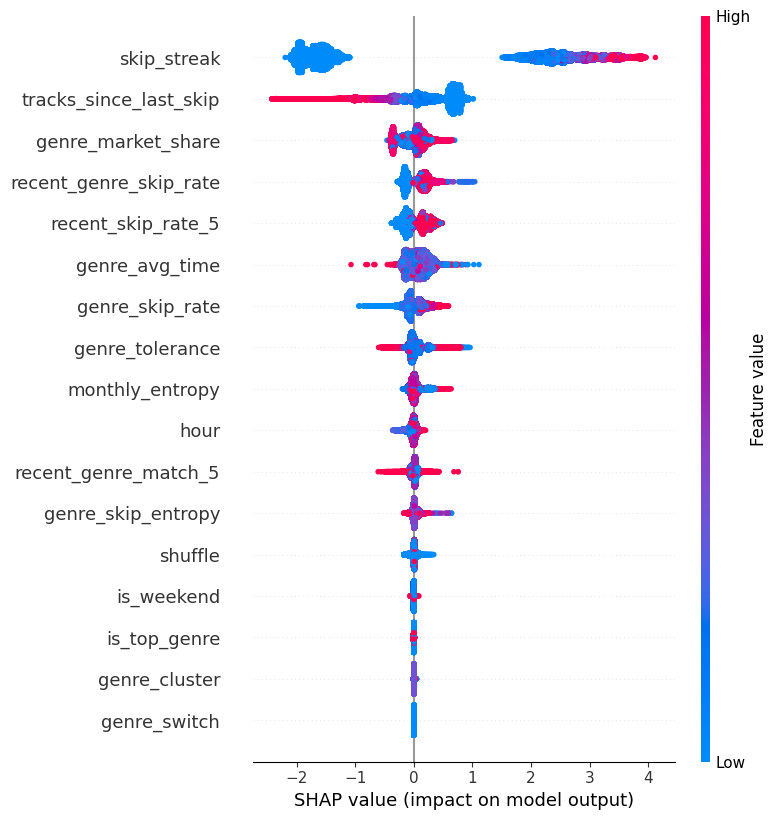

In [103]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values, X_test)

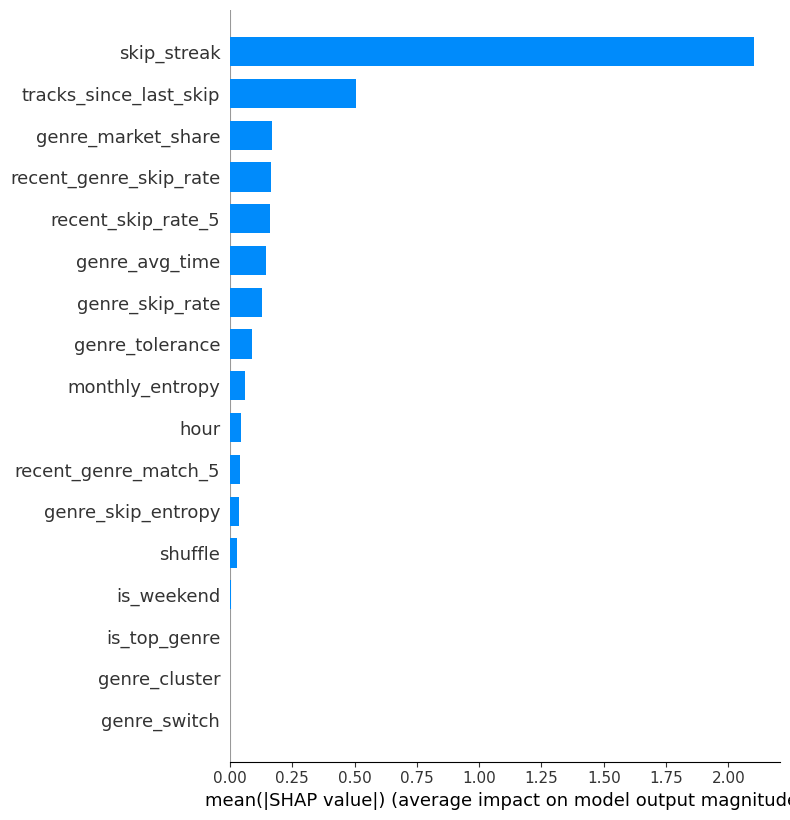

In [104]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

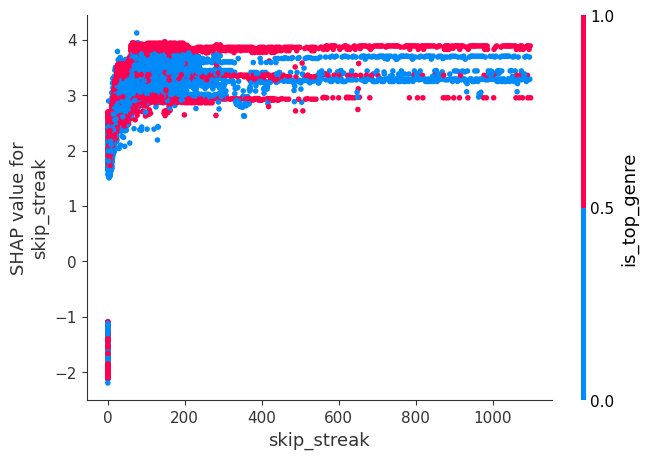

In [106]:
shap.dependence_plot("skip_streak", shap_values, X_test) 

# Trocar pela feature que aparecer como mais importante
 